In [85]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## Q2

Starting Vertex: 0

## Q3

In [86]:
dist_matrix = np.loadtxt('data/ha30_dist.txt')
positions = np.loadtxt('data/ha30_xyz.txt')
with open('data/ha30_name.txt') as f:
    city_list = f.readlines()

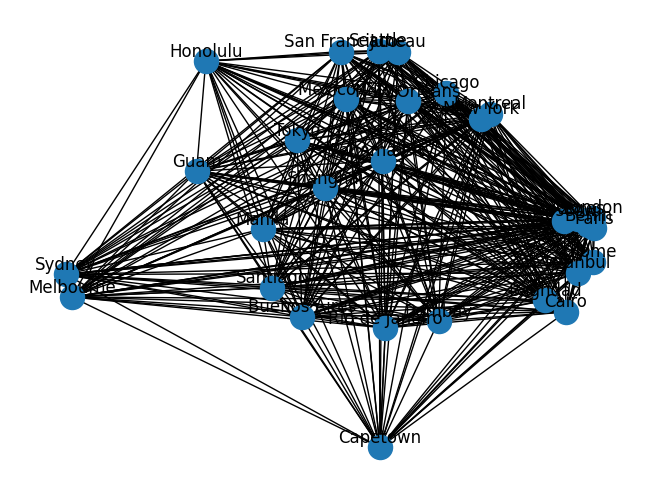

In [87]:
G_q3 = nx.Graph()
for i in range(len(city_list)):
    G_q3.add_node(city_list[i], pos=(positions[i, 0], positions[i, 1]))

for i in range(G_q3.number_of_nodes()):
    for j in range(i + 1, G_q3.number_of_nodes()):
        G_q3.add_edge(city_list[i], city_list[j], weight=dist_matrix[i][j])

pos = nx.get_node_attributes(G_q3, 'pos')
nx.draw(G_q3, pos, with_labels=True)
plt.show()

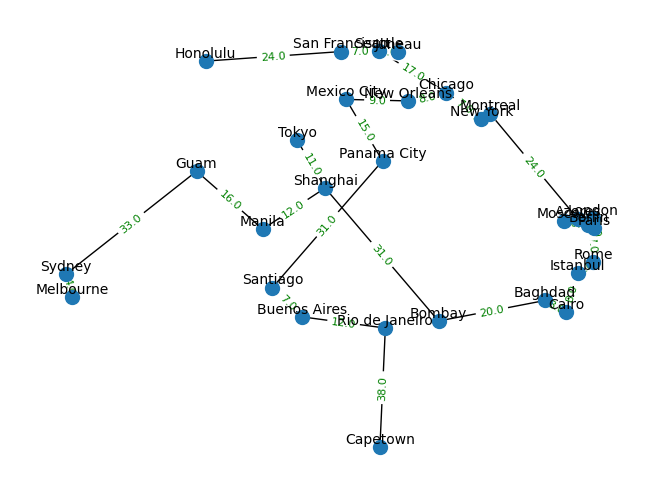

In [104]:
T = nx.minimum_spanning_tree(G_q3)

pos = nx.get_node_attributes(T, 'pos')
labels = nx.get_edge_attributes(T, 'weight')

nx.draw(T, pos=pos, with_labels=True, font_size=10, node_size=100)
nx.draw_networkx_edge_labels(T, pos=pos, edge_labels=labels, font_size=8, font_color='green')
plt.show()

In [89]:
edge_data = [
    {'source': src[:-1], 'destination': dest[:-1], 'distance': dist['weight']}
    for src, dest, dist in T.edges(data=True)
]
pd.DataFrame(edge_data)

,source,destination,distance
0,Azores,London,16.0
1,Azores,Montreal,24.0
2,Baghdad,Cairo,8.0
3,Baghdad,Bombay,20.0
4,Berlin,Paris,5.0
5,Berlin,Rome,7.0
6,Berlin,Moscow,10.0
7,Bombay,Shanghai,31.0
8,Buenos Aires,Santiago,7.0
9,Buenos Aires,Rio de Janeiro,12.0


In [90]:
print("Total", sum([T[i][j]['weight'] for (i, j) in T.edges()]))

Total 403.0


## Q4

Non-isomorphic tree count of order  7  is  11


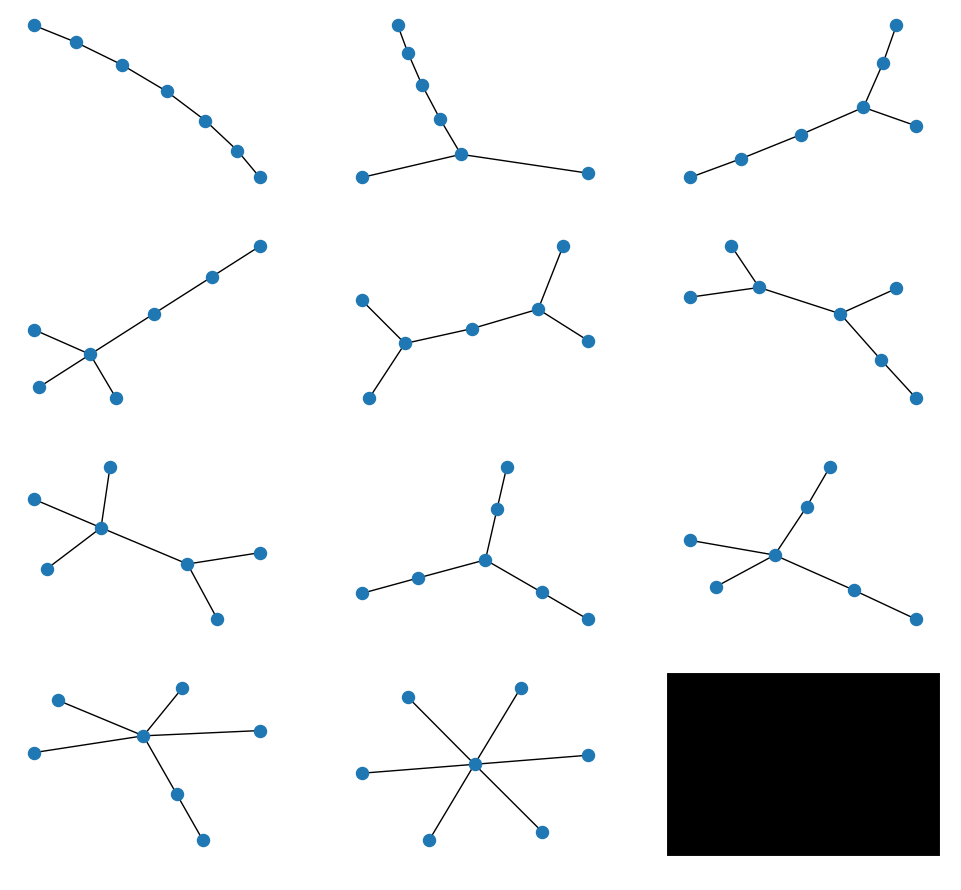

In [91]:
order = 7
GList = [G for G in nx.nonisomorphic_trees(order)]

isom_count = len(GList)
print("Non-isomorphic tree count of order ", order, " is ", isom_count)

fig, axes = plt.subplots(4, 3, figsize=(12, isom_count))
axes = axes.flat

for G, ax in zip(GList, axes):
    nx.draw(G, ax=ax, node_size=75)

plt.show()

## Q5

2 invalid graphs